In [23]:
!pip install --quiet rasterio
!pip install --quiet --upgrade gdown

In [24]:
!gdown https://drive.google.com/uc?id=1Qw96Drmk2jzBYSED0YPEUyuc2DnBechl

Downloading...
From (original): https://drive.google.com/uc?id=1Qw96Drmk2jzBYSED0YPEUyuc2DnBechl
From (redirected): https://drive.google.com/uc?id=1Qw96Drmk2jzBYSED0YPEUyuc2DnBechl&confirm=t&uuid=8aed473c-a3b4-458d-a9d0-0e7c3b1ad182
To: c:\Users\gamer\Documents\projets\methane-detection-starcop\notebooks\STARCOP_mini.zip

  0%|          | 0.00/274M [00:00<?, ?B/s]
  1%|          | 2.62M/274M [00:00<00:10, 25.2MB/s]
  4%|▎         | 9.96M/274M [00:00<00:05, 51.9MB/s]
  6%|▌         | 16.8M/274M [00:00<00:04, 58.9MB/s]
  8%|▊         | 23.1M/274M [00:00<00:06, 40.1MB/s]
 11%|█         | 30.4M/274M [00:00<00:05, 48.2MB/s]
 13%|█▎        | 36.2M/274M [00:00<00:05, 45.4MB/s]
 15%|█▌        | 41.4M/274M [00:00<00:05, 43.3MB/s]
 17%|█▋        | 46.7M/274M [00:01<00:06, 35.3MB/s]
 19%|█▊        | 50.9M/274M [00:01<00:06, 35.5MB/s]
 20%|██        | 55.1M/274M [00:01<00:05, 36.8MB/s]
 22%|██▏       | 61.3M/274M [00:01<00:04, 43.1MB/s]
 24%|██▍       | 66.1M/274M [00:01<00:06, 32.8MB/s]
 27%|██▋ 

In [25]:
import os
from glob import glob
public_folder = "." # because we downloaded these locally
files_to_extract = sorted(glob(os.path.join(public_folder,"*.zip")))
print("All:",files_to_extract)

All: ['.\\STARCOP_mini.zip']


In [26]:
import zipfile
from tqdm import tqdm

dataset_folder = "./datasets"
os.makedirs(dataset_folder, exist_ok=True)

for zip_files in tqdm(files_to_extract):
  with zipfile.ZipFile(zip_files, "r") as zip_ref:
    zip_ref.extractall(dataset_folder)
    zip_ref.close()

100%|██████████| 1/1 [00:01<00:00,  1.85s/it]


In [27]:
!rm *.zip

'rm' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [28]:
folders_in_test = sorted(glob(os.path.join(dataset_folder,"STARCOP_test/*")))
folders_in_test = [f for f in folders_in_test if ".csv" not in f]

print("We have", len(folders_in_test), "folders in the test set.")

folders_in_train_easy = sorted(glob(os.path.join(dataset_folder,"STARCOP_train_easy/*")))
folders_in_train_easy = [f for f in folders_in_train_easy if ".csv" not in f]
print("And we have", len(folders_in_train_easy), "folders in the train_easy subset.")

folders_in_mini = sorted(glob(os.path.join(dataset_folder,"STARCOP_mini/*")))
folders_in_mini = [f for f in folders_in_mini if ".csv" not in f]
print("And we have", len(folders_in_mini), "folders in the mini subset.")

print("\n--\n")

print("Each folder has these files:")
!ls {folders_in_mini[0]}

We have 0 folders in the test set.
And we have 0 folders in the train_easy subset.
And we have 18 folders in the mini subset.

--

Each folder has these files:


'ls' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [29]:
print("These are the available csv files:")
!ls datasets/*/*.csv

These are the available csv files:


'ls' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [30]:
visualise_folder = "datasets/STARCOP_mini" # "datasets/STARCOP_test" # "datasets/STARCOP_train_easy"

csv_file = "datasets/STARCOP_mini/test_mini10.csv"

In [31]:
import rasterio.plot as rstplt
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable

def hide_all_ticks(ax, hide_border=False):
    # hide all ticks
    ax.xaxis.set_tick_params(labelbottom=False)
    ax.yaxis.set_tick_params(labelleft=False)
    ax.set_xticks([])
    ax.set_yticks([])

    #hide border
    if hide_border: ax.axis('off')

def colorbar_next_to(im, ax, size='5%',pad=0.05):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size=size, pad=pad)
    plt.gcf().colorbar(im, cax=cax, orientation='vertical')

def maintain_same_sizes(im, ax, size='5%',pad=0.05):
    # creates and deletes a fake colorbar - to maintain the same plot sizes
    colorbar_next_to(im, ax, size=size, pad=pad)
    fig.delaxes(fig.axes[-1])

In [90]:
import pandas as pd
import os
csv_path = os.path.join('..', 'data', f'STARCOP_train_easy', f'train_easy.csv')
df = pd.read_csv(csv_path)
df = df.sort_values(by=['qplume'], ascending=False)

In [81]:
df[df['qplume'] > 0].describe()

,qplume,window_col_off,window_row_off,window_width,window_height
count,273.000000,273.0,273.0,273.0,273.0
mean,1860.577578,0.0,0.0,512.0,512.0
std,1240.814764,0.0,0.0,0.0,0.0
min,1000.844290,0.0,0.0,512.0,512.0
25%,1165.981070,0.0,0.0,512.0,512.0
50%,1512.570280,0.0,0.0,512.0,512.0
75%,2091.773870,0.0,0.0,512.0,512.0
max,11239.539700,0.0,0.0,512.0,512.0


In [69]:
df['subset'].unique()

array(['train'], dtype=object)

Using 4 bins based on Sturges' formula (capped at 4)
Stratifying qplume into 4 bins (excluding zeros)
Répartition des nouveaux bins :
total_bin
0    286
1    132
2     60
3     35
4     18
Name: count, dtype: int64


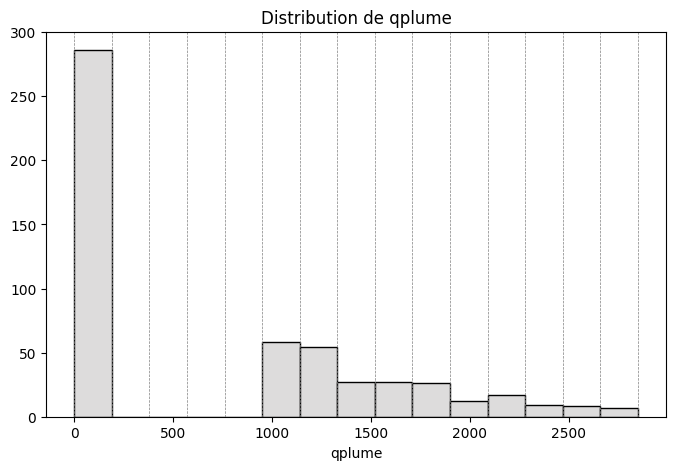

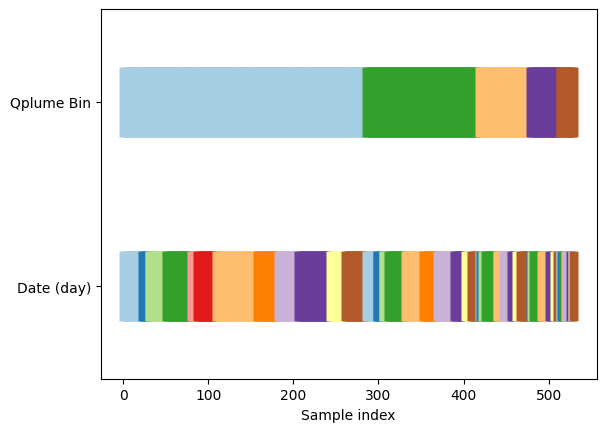

In [ ]:
import matplotlib.pyplot as plt
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm
from sklearn.preprocessing import LabelEncoder
import numpy as np
import joypy

""" num_bins = min(10, int(np.floor(1 + np.log2(len(df)))))
print(f"Stratifying qplume into {num_bins} bins")

df['total_bin'] = pd.cut(
    df['qplume'], 
    bins=num_bins, 
    labels=False,
    duplicates='drop'  # Remove duplicate edges
) """

def create_methane_bins(df, column='qplume'):

    df = df.copy()
    
    seuil_95 = df[column].quantile(0.95)
    df = df[df[column] <= seuil_95].copy()
    
    is_positive = df[column] > 0
    
    n_bins =int(np.floor(1 + np.log2(len(is_positive))))
    print(f"Using {n_bins} bins based on Sturges' formula")


    df['total_bin'] = 0
    
    if is_positive.any():
        df.loc[is_positive, 'total_bin'] = pd.cut(
            df.loc[is_positive, column], 
            bins=n_bins, 
            labels=False, 
            duplicates='drop'
        ) + 1
    
    return df


num_bins = 15
df = create_methane_bins(df)

print("Répartition des nouveaux bins :")
print(df['total_bin'].value_counts().sort_index())

plt.figure(figsize=(8, 5))

plt.hist(df['qplume'].dropna(), bins=num_bins,
         color=cmap_cv(0.5), edgecolor='black')

bin_edges = np.linspace(df['qplume'].min(), df['qplume'].max(), num_bins+1)
for e in bin_edges:
    plt.axvline(e, color='gray', linestyle='--', linewidth=0.5)

plt.xlabel(f"qplume")
plt.title(f"Distribution de qplume")
plt.show()




def visualize_groups(classes, groups, name):
    # Visualize dataset groups
    
    fig, ax = plt.subplots()
    ax.scatter(
        range(len(groups)),
        [0.5] * len(groups),
        c=groups,
        marker="_",
        lw=50,
        cmap=cmap_data,
    )
    ax.scatter(
        range(len(groups)),
        [3.5] * len(groups),
        c=classes,
        marker="_",
        lw=50,
        cmap=cmap_data,
    )
    ax.set(
        ylim=[-1, 5],
        yticks=[0.5, 3.5],
        yticklabels=["Date (day)", "Qplume Bin"],
        xlabel="Sample index",
    )



df = df.sort_values("total_bin").reset_index(drop=True)
df["date"] = pd.to_datetime(
    df["date"]
)

df["date"] = df["date"].dt.day
bin_order = sorted(df["total_bin"].unique())

train_sorted = (
    df
    .assign(
        total_bin=pd.Categorical(
            df["total_bin"],
            categories=bin_order,
            ordered=True
        )
    )
    .sort_values(["total_bin", "date"])
    .reset_index(drop=True)
)


visualize_groups(
    classes=train_sorted["total_bin"].astype("category").cat.codes,
    groups=train_sorted["date"].astype("category").cat.codes,
    name="Ordered by bin → Date"
)

In [40]:
df['total_bin'].unique()

array([0, 1, 2, 3, 4, 5, 6, 9])

<Axes: title={'center': 'StratifiedGroupKFold'}, xlabel='Sample index', ylabel='CV iteration'>

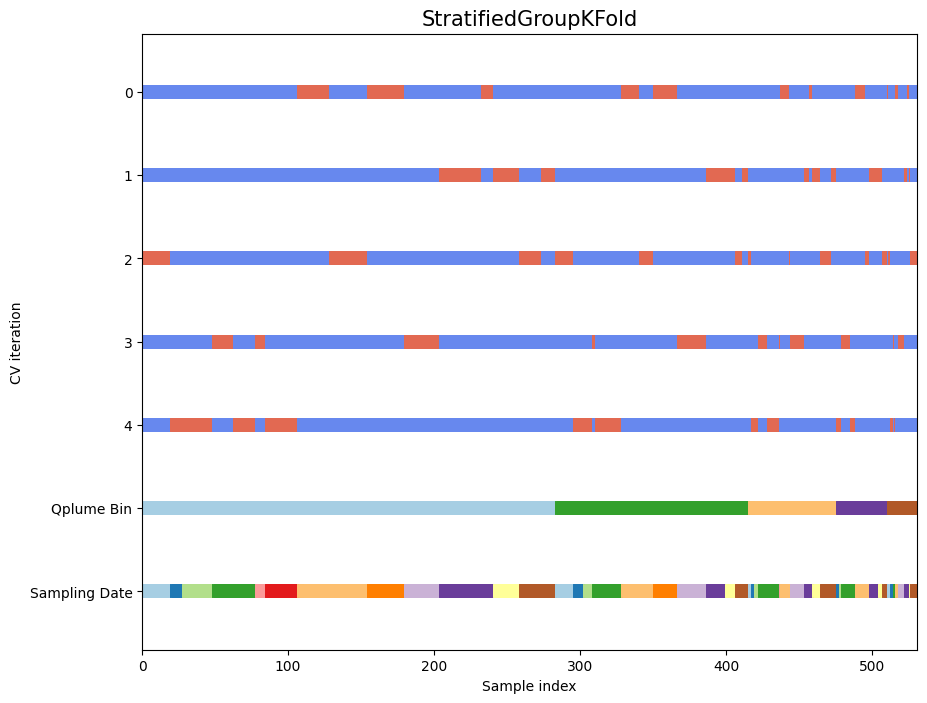

In [89]:
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    KFold,
    ShuffleSplit,
    StratifiedGroupKFold,
    StratifiedKFold,
    StratifiedShuffleSplit,
    TimeSeriesSplit,
)

def plot_cv_indices(cv, X, y, group, ax, n_splits, lw=10):
    """Create a sample plot for indices of a cross-validation object."""
    use_groups = "Group" in type(cv).__name__
    groups = group if use_groups else None
    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=groups)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=lw,
            cmap=cmap_cv,
            vmin=-0.2,
            vmax=1.2,
        )

    # Plot the data classes and groups at the end
    ax.scatter(
        range(len(X)), [ii + 1.5] * len(X), c=y, marker="_", lw=lw, cmap=cmap_data
    )

    ax.scatter(
        range(len(X)), [ii + 2.5] * len(X), c=group, marker="_", lw=lw, cmap=cmap_data
    )

    # Formatting
    yticklabels = list(range(n_splits)) + ["Qplume Bin", "Sampling Date"]
    ax.set(
        yticks=np.arange(n_splits + 2) + 0.5,
        yticklabels=yticklabels,
        xlabel="Sample index",
        ylabel="CV iteration",
        ylim=[n_splits + 2.2, -0.2],
        xlim=[0, len(X)],
    )
    ax.set_title("{}".format(type(cv).__name__), fontsize=15)
    return ax

n_splits = 5
fig, ax = plt.subplots(figsize = (10,8))
cv = StratifiedGroupKFold(n_splits, shuffle = True, random_state = 42)
plot_cv_indices(cv, train_sorted.drop(columns = ['total_bin', 'date']), train_sorted["total_bin"].astype("category").cat.codes, train_sorted["date"].astype("category").cat.codes, ax, n_splits)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.7064283].


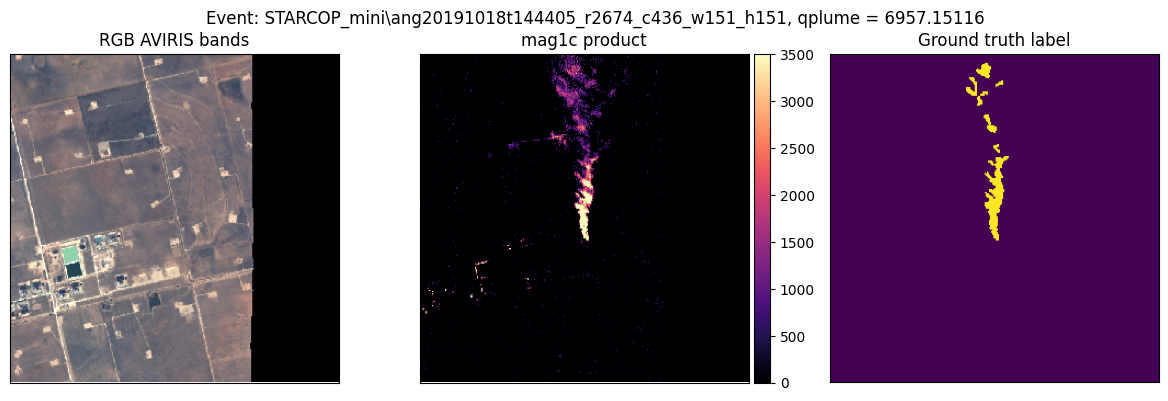

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].


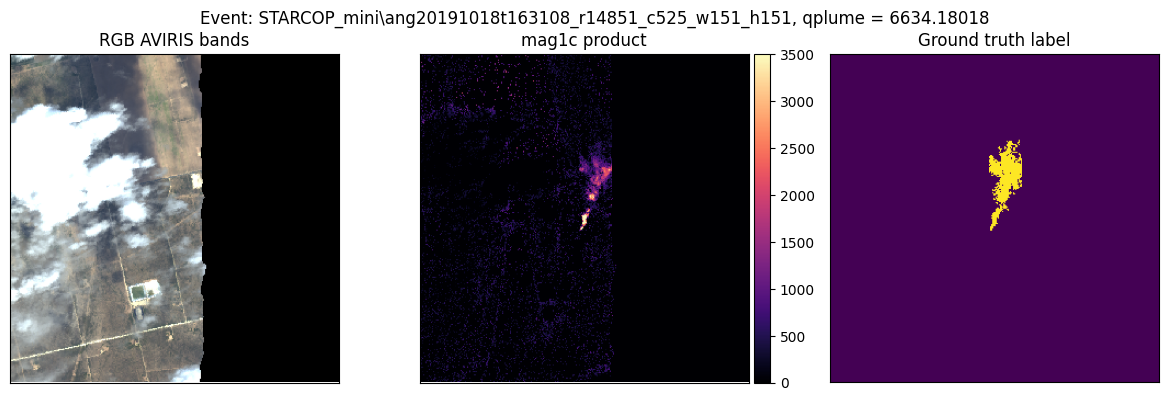

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.11730166..1.4973282].


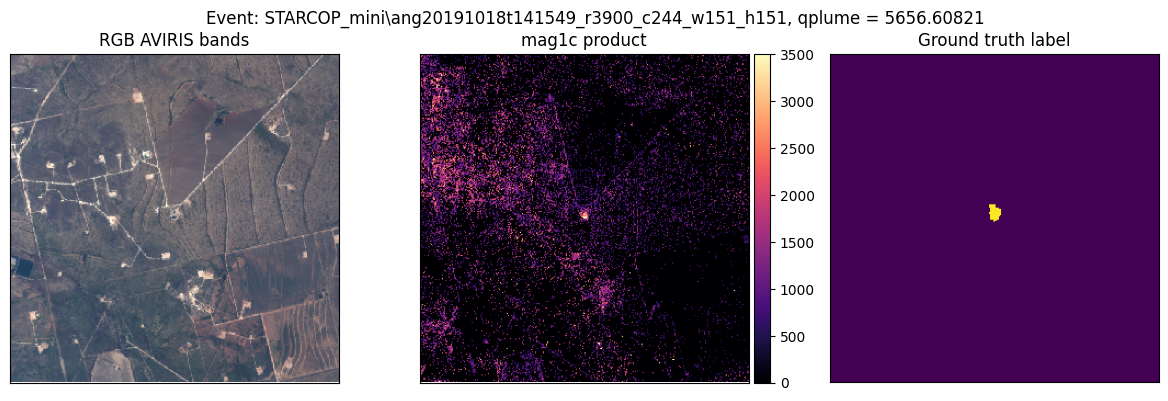

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.6921006].


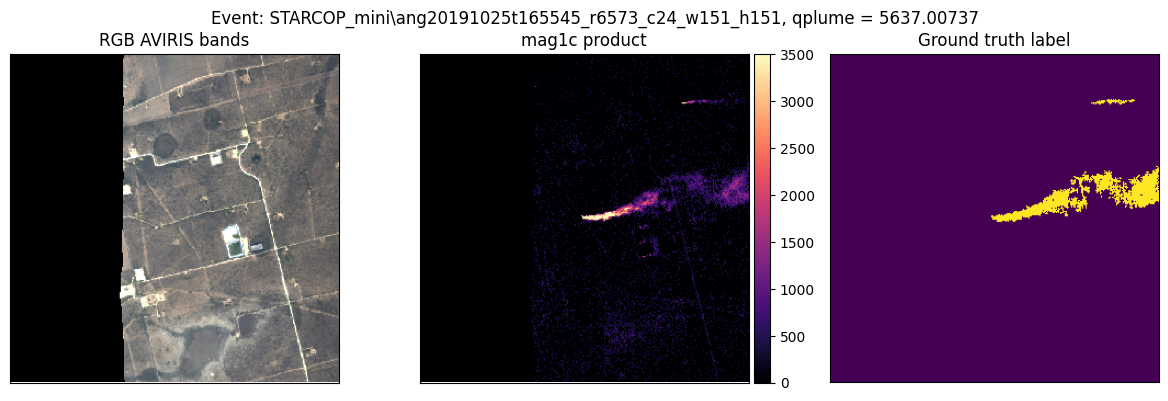

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].


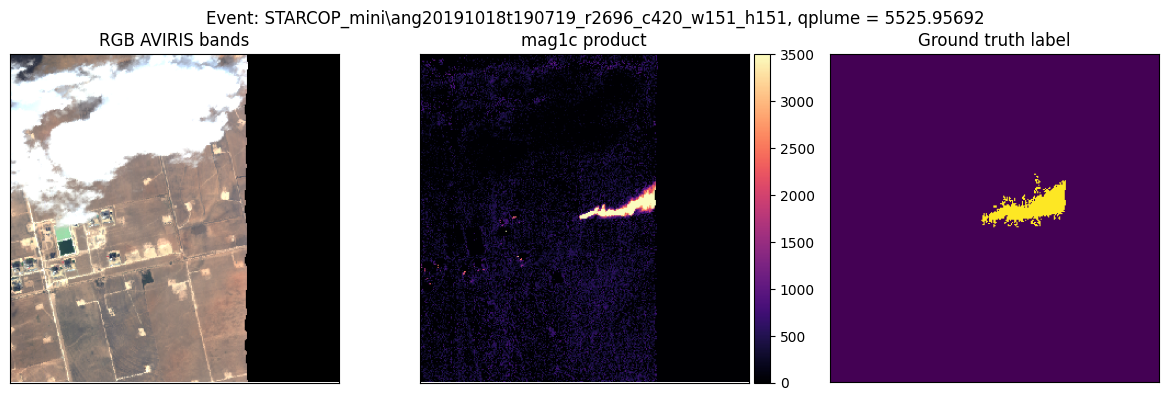

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3675122].


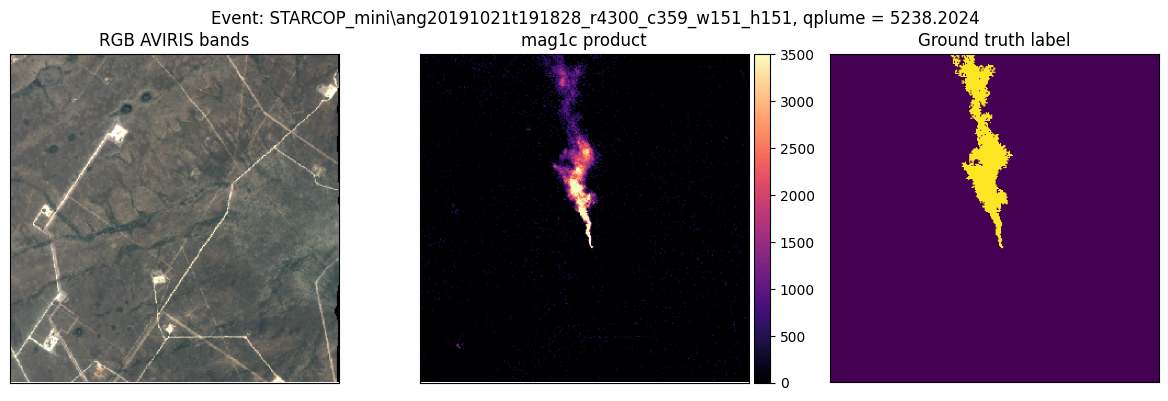

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].


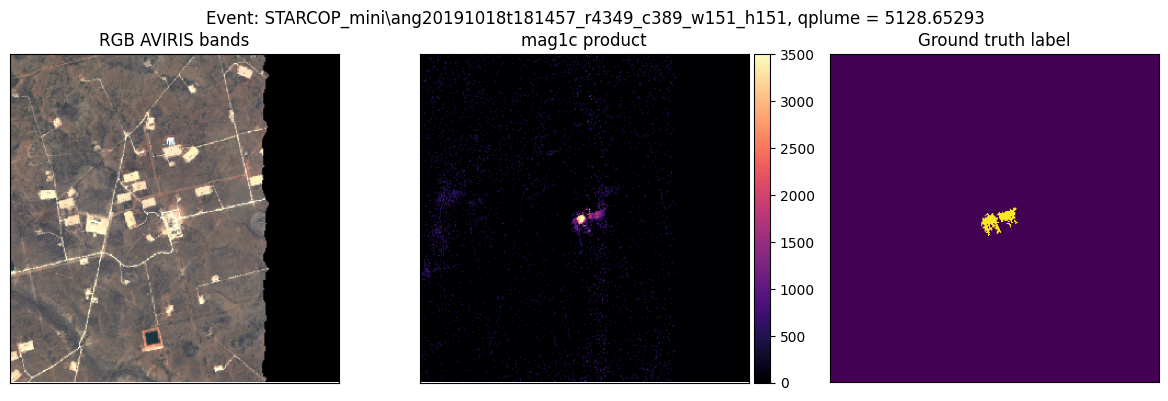

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.6136265].


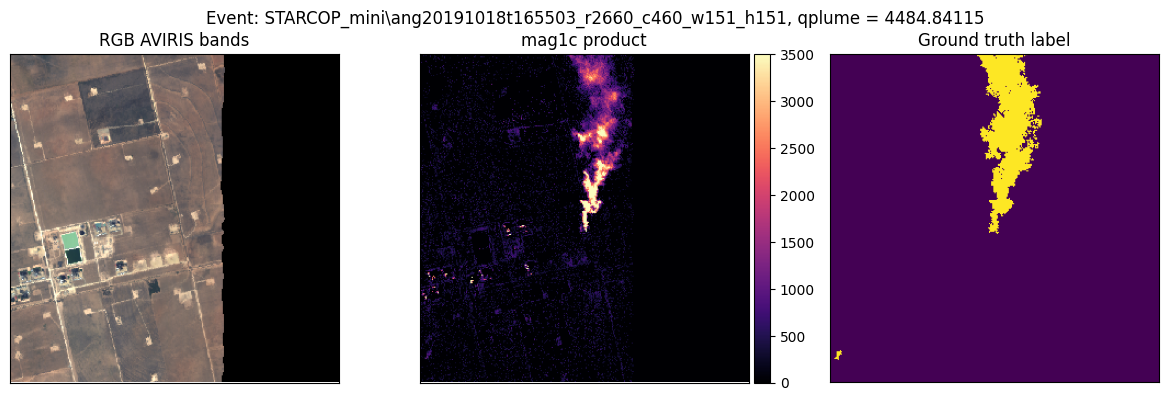

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].


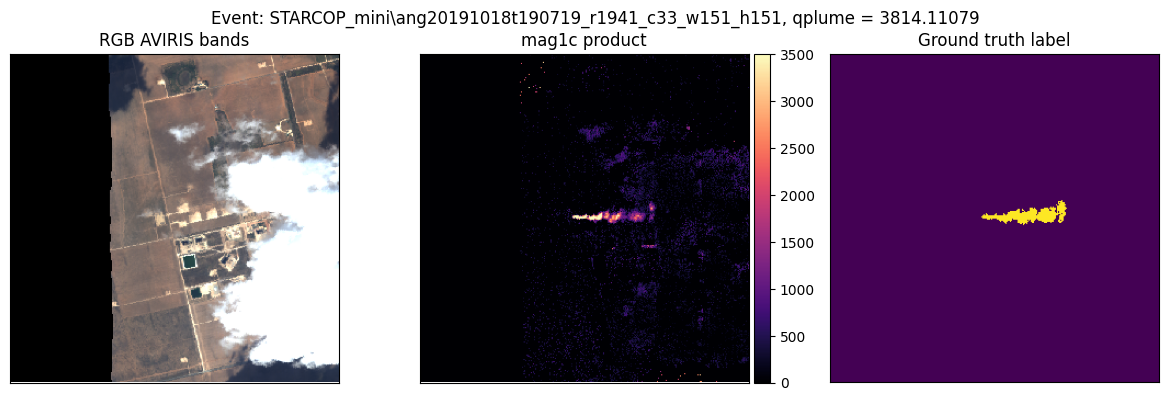

In [33]:
size_read = 300
show_first = 10
fig_size_multiplier = 4
csv_path = os.path.join('datasets', 'STARCOP_mini', 'test_mini10.csv')
df = pd.read_csv(csv_path)
df = df.sort_values(by=['qplume'], ascending=False)
for idx, event_id in enumerate(list(df["id"])):
  ft = os.path.join(visualise_folder, event_id)
  # Typical input for our hyperspectral model: RGB + mag1c
  aviris_r = os.path.join(ft, "TOA_AVIRIS_640nm.tif")
  aviris_g = os.path.join(ft, "TOA_AVIRIS_550nm.tif")
  aviris_b = os.path.join(ft, "TOA_AVIRIS_460nm.tif")
  magic_path = os.path.join(ft, "mag1c.tif")
  # Ground truth:
  gt_path = os.path.join(ft, "labelbinary.tif")
  n_plots = 3

  with rasterio.open(gt_path) as src:
    width = src.width
    height = src.height

    # Compute shape to read to from pyramids and speed up plotting
    shape = src.shape
    if (size_read >= shape[0]) and (size_read >= shape[1]):
      out_shape = shape
    elif shape[0] > shape[1]:
      out_shape = (size_read, int(round(shape[1]/shape[0] * size_read)))
    else:
      out_shape = (int(round(shape[0] / shape[1] * size_read)), size_read)
    gt = src.read(1, out_shape=out_shape)

  with rasterio.open(magic_path) as src:
    magic = src.read(1, out_shape=out_shape)
  with rasterio.open(aviris_r) as src:
    r = src.read(1, out_shape=out_shape)
  with rasterio.open(aviris_g) as src:
    g = src.read(1, out_shape=out_shape)
  with rasterio.open(aviris_b) as src:
    b = src.read(1, out_shape=out_shape)

  rgb = np.asarray([r,g,b])

  fig, axes = plt.subplots(1, n_plots, figsize=(n_plots*fig_size_multiplier*width/height,fig_size_multiplier), tight_layout=True)

  # Plot GT
  ax = axes[-1]
  im=ax.imshow(gt)
  ax.set_title(f"Ground truth label")
  hide_all_ticks(ax)
  maintain_same_sizes(im,ax)

  # Plot RGB
  ax = axes[0]
  rgb = np.clip(rgb/60., 0, 2)
  im = ax.imshow(np.transpose(np.asanyarray(rgb),(1,2,0)))
  ax.set_title(f"RGB AVIRIS bands")
  hide_all_ticks(ax)
  maintain_same_sizes(im,ax)

  # mag1c
  ax = axes[1]
  im=ax.imshow(1750 * np.clip(magic / 1750.0, 0,2))
  im.set_cmap('magma')
  ax.set_title(f"mag1c product")
  hide_all_ticks(ax)
  colorbar_next_to(im, ax)

  name = ft.split("/")[-1]
  qplume = df["qplume"][idx]

  plt.suptitle(f"Event: {name}, qplume = {qplume}")
  plt.show()
  # note: below left with the first two outputs as a demo

  show_first -= 1
  if show_first <= 0: break